# Task 1 of the Project

## Setup and Data Loading

In [45]:
import json
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

INPUT_FILE = 'example_json/input.json'
OUTPUT_FILE = 'output.json'
TOP_VIEW_OUTPUT = 'top_views_output.json'
TOP_VIEW_DIR = 'top_views'
BOUNDING_BOX_OUTPUT = 'bounding_boxes_output.json'
BOUNDING_BOX_DIR = 'bounding_boxes'

os.makedirs(TOP_VIEW_DIR, exist_ok=True)
os.makedirs(BOUNDING_BOX_DIR, exist_ok=True)

try:
    with open(INPUT_FILE, 'r') as f:
        input_data = json.load(f)
        
    image_paths = input_data.get("image_path", [])
    print(f"Successfully loaded {len(image_paths)} image paths from '{INPUT_FILE}'.")
    
    """
    # Load and display the first image to verify everything is working
    if len(image_paths) > 0:
        first_image_path = 'development_set/22f_png.rf.5f4dedb3e61ea2ced7d183a74035d313.jpg'
        print(f"\nTesting image load for: {first_image_path}")
        
        img = cv2.imread(first_image_path)
        
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(10, 6))
            plt.imshow(img_rgb)
            plt.axis('off')
            plt.show()
        else:
            print(f"ERROR: Could not read the image at '{first_image_path}'.")
    """

except FileNotFoundError:
    print(f"ERROR: The file '{INPUT_FILE}' was not found.")

Successfully loaded 50 image paths from 'example_json/input.json'.


## Top-View Generation

In [46]:
from itertools import combinations

def select_best_quadrilateral(corners, debug=False):
    """
    When approxPolyDP returns more than 4 points, this function
    tries all combinations of 4 points and returns the one that
    forms the most "rectangle-like" quadrilateral.
    
    Scoring criteria:
    - Larger area is better (we want the full table)
    - Convexity is required
    - Angles closer to 90° are better
    - Opposite sides should be similar length
    """
    
    points = corners.reshape(-1, 2)
    n_points = len(points)
    
    if debug:
        print(f"\n=== SELECT BEST QUADRILATERAL ===")
        print(f"Input points ({n_points}): {points.tolist()}")
    
    def quadrilateral_score(quad):
        # Order points consistently (convex hull ordering)
        hull = cv2.convexHull(quad.astype(np.float32))
        if len(hull) != 4:
            return None, "non-convex"
        
        ordered = hull.reshape(4, 2)
        
        # Calculate area
        area = cv2.contourArea(ordered)
        if area < 1000:
            return None, "too small"
        
        # Calculate angles at each corner
        angles = []
        for i in range(4):
            p1 = ordered[(i - 1) % 4]
            p2 = ordered[i]
            p3 = ordered[(i + 1) % 4]
            
            v1 = p1 - p2
            v2 = p3 - p2
            
            cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
            cos_angle = np.clip(cos_angle, -1, 1)
            angle = np.degrees(np.arccos(cos_angle))
            angles.append(angle)
        
        angle_deviation = sum(abs(a - 90) for a in angles)
        
        # Check opposite sides ratio
        side_lengths = [np.linalg.norm(ordered[(i + 1) % 4] - ordered[i]) for i in range(4)]
        ratio1 = min(side_lengths[0], side_lengths[2]) / (max(side_lengths[0], side_lengths[2]) + 1e-8)
        ratio2 = min(side_lengths[1], side_lengths[3]) / (max(side_lengths[1], side_lengths[3]) + 1e-8)
        side_ratio_score = (ratio1 + ratio2) / 2
        
        # Combined score: prioritize area, then rectangularity
        score = area * side_ratio_score / (1 + angle_deviation * 0.01)
        
        return score, ordered
    
    best_score = None
    best_quad = None
    
    for combo in combinations(range(n_points), 4):
        quad = points[list(combo)]
        result = quadrilateral_score(quad)
        
        if result[0] is None:
            if debug:
                print(f"  combo {combo}: INVALID ({result[1]})")
            continue
        
        score, ordered = result
        if debug:
            print(f"  combo {combo}: score={score:.2f}")
        
        if best_score is None or score > best_score:
            best_score = score
            best_quad = ordered
    
    if best_quad is None:
        if debug:
            print("  No valid quadrilateral found!")
        return None
    
    if debug:
        print(f"  BEST quad: {best_quad.tolist()} with score={best_score:.2f}")
    
    return best_quad.reshape(4, 1, 2).astype(np.int32)

def detect_white_dots(img_hsv, img_rgb, corners, debug=False):
    def merge_close_dots(dots, dist_thresh):
        if not dots:
            return []

        pts = np.array([[x, y] for x, y, _ in dots], dtype=np.float32)
        areas = np.array([a for _, _, a in dots], dtype=np.float32)

        visited = np.zeros(len(dots), dtype=bool)
        merged = []

        if debug:
            print("\n=== MERGE CLOSE DOTS ===")
            print(f"input dots: {len(dots)} | dist_thresh={dist_thresh}")

        for i in range(len(dots)):
            if visited[i]:
                continue

            stack = [i]
            cluster = []

            while stack:
                idx = stack.pop()
                if visited[idx]:
                    continue

                visited[idx] = True
                cluster.append(idx)

                for j in range(len(dots)):
                    if not visited[j]:
                        d = np.linalg.norm(pts[idx] - pts[j])
                        if d < dist_thresh:
                            stack.append(j)

            cluster_pts = pts[cluster]
            cluster_areas = areas[cluster]

            total_area = float(cluster_areas.sum())
            cx = int(np.average(cluster_pts[:, 0], weights=cluster_areas))
            cy = int(np.average(cluster_pts[:, 1], weights=cluster_areas))

            merged.append((cx, cy, total_area))

            if debug:
                members = [tuple(map(int, pts[k])) for k in cluster]
                print(
                    f"cluster size={len(cluster)} | members={members} -> "
                    f"merged=({cx}, {cy}) | total_area={total_area:.2f}"
                )

        if debug:
            print(f"merged dots: {len(merged)}")

        return merged

    def point_to_segment_distance(pt, a, b):
        pt = np.array(pt, dtype=np.float32)
        a = np.array(a, dtype=np.float32)
        b = np.array(b, dtype=np.float32)

        ab = b - a
        denom = np.dot(ab, ab) + 1e-8
        t = np.dot(pt - a, ab) / denom
        t = np.clip(t, 0.0, 1.0)

        proj = a + t * ab
        return float(np.linalg.norm(pt - proj))

    def filter_dots_near_border(dots, corners, max_border_dist):
        corners = np.array(corners, dtype=np.float32).reshape(4, 2)

        edges = []
        for i in range(4):
            a = corners[i]
            b = corners[(i + 1) % 4]
            edges.append((a, b))

        filtered = []

        if debug:
            print("\n=== FILTER DOTS NEAR BORDER ===")
            print(f"input dots: {len(dots)} | max_border_dist={max_border_dist}")

        for x, y, area in dots:
            p = (x, y)
            dists = [point_to_segment_distance(p, a, b) for a, b in edges]
            min_dist = min(dists)

            if debug:
                dists_str = " | ".join([f"e{i}={d:.2f}" for i, d in enumerate(dists)])
                status = "KEEP" if min_dist <= max_border_dist else "DROP"
                print(
                    f"dot ({x}, {y}) area={area:.2f} -> {dists_str} | "
                    f"min_dist={min_dist:.2f} -> {status}"
                )

            if min_dist <= max_border_dist:
                filtered.append((x, y, area))

        if debug:
            print(f"kept after border filter: {len(filtered)}")

        return filtered

    lower_white = np.array([0, 0, 180])
    upper_white = np.array([180, 50, 255])

    white_mask = cv2.inRange(img_hsv, lower_white, upper_white)
    contours, _ = cv2.findContours(white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    min_area = 1
    max_area = 120

    raw_dots = []

    if debug:
        print("\n=== WHITE DOT DETECTION ===")
        print(f"white HSV range: lower={lower_white.tolist()} upper={upper_white.tolist()}")
        print(f"contours found: {len(contours)}")
        print(f"area filter: {min_area} < area < {max_area}")

    for idx, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)

        if debug:
            print(f"contour {idx}: area={area:.2f}", end="")

        if min_area < area < max_area:
            M = cv2.moments(cnt)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                raw_dots.append((cx, cy, area))

                if debug:
                    print(f" -> KEEP raw_dot=({cx}, {cy})")
            else:
                if debug:
                    print(" -> DROP (m00 == 0)")
        else:
            if debug:
                reason = "too small" if area <= min_area else "too large"
                print(f" -> DROP ({reason})")

    if debug:
        print(f"\nraw dots kept after area filter: {len(raw_dots)}")
        print(f"raw dots: {raw_dots}")

    dots = merge_close_dots(raw_dots, dist_thresh=50)

    if debug:
        print(f"\nafter merge_close_dots: {len(dots)}")
        print(f"merged dots: {dots}")

    dots = filter_dots_near_border(dots, corners, max_border_dist=100)

    if debug:
        print(f"\nfinal dots after border filter: {len(dots)}")
        print(f"final dots: {dots}")

        img_debug = img_rgb.copy()
        for cx, cy, area in dots:
            cv2.circle(img_debug, (cx, cy), 8, (0, 255, 0), 2)

        filtered_mask = np.zeros_like(white_mask)
        for cx, cy, area in dots:
            cv2.circle(filtered_mask, (cx, cy), 6, 255, -1)

        fig, ax = plt.subplots(1, 3, figsize=(16, 5))
        ax[0].imshow(white_mask, cmap='gray')
        ax[0].set_title("White Mask")

        ax[1].imshow(img_debug)
        ax[1].set_title(f"Detected Dots ({len(dots)})")

        ax[2].imshow(filtered_mask, cmap='gray')
        ax[2].set_title("Filtered")

        plt.tight_layout()
        plt.show()

    return dots

def find_side_triplets(dots, src_pts, line_tol, dist_tol, debug=False):
    pts = np.array([[x, y] for x, y, _ in dots], dtype=np.float32)
    corners = np.array(src_pts, dtype=np.float32).reshape(4, 2)

    def point_to_segment_distance_and_t(p, a, b):
        ab = b - a
        denom = np.dot(ab, ab) + 1e-8
        t = np.dot(p - a, ab) / denom
        t_clip = np.clip(t, 0.0, 1.0)
        proj = a + t_clip * ab
        dist = np.linalg.norm(p - proj)
        return float(dist), float(t)

    def triplet_score(p1, p2, p3, return_metrics=False):
        fit = cv2.fitLine(
            np.array([p1, p2, p3], dtype=np.float32),
            cv2.DIST_L2,
            0,
            0.01,
            0.01
        )
        vx, vy, x0, y0 = [float(v.item()) for v in fit]

        residuals = [abs(vx * (p[1] - y0) - vy * (p[0] - x0)) for p in [p1, p2, p3]]
        line_err = float(np.mean(residuals))

        d12 = float(np.linalg.norm(np.array(p1) - np.array(p2)))
        d23 = float(np.linalg.norm(np.array(p2) - np.array(p3)))

        if min(d12, d23) < 1e-8:
            if return_metrics:
                return None, line_err, None, d12, d23
            return None

        rel_err = abs(d12 - d23) / max(d12, d23)

        if line_err > line_tol or rel_err > dist_tol:
            if return_metrics:
                return None, line_err, rel_err, d12, d23
            return None

        score = line_err + 50.0 * rel_err

        if return_metrics:
            return score, line_err, rel_err, d12, d23
        return score

    edges = []
    for i in range(4):
        a = corners[i]
        b = corners[(i + 1) % 4]
        edges.append({
            "idx": i,
            "a": tuple(map(int, a)),
            "b": tuple(map(int, b)),
            "assigned_pts": [],
            "ordered_points": [],
            "triplets": []
        })

    if debug:
        print("\n=== POINT ASSIGNMENT ===")

    for p in pts:
        best_edge = None
        best_dist = None
        best_t = None
        dists = []

        for i in range(4):
            a = corners[i]
            b = corners[(i + 1) % 4]
            d, t = point_to_segment_distance_and_t(p, a, b)
            dists.append((i, d, t))

            if best_dist is None or d < best_dist:
                best_dist = d
                best_t = t
                best_edge = i

        if debug:
            p_int = tuple(map(int, p))
            dists_str = " | ".join([f"e{i}: d={d:.1f}, t={t:.3f}" for i, d, t in dists])
            print(f"Point {p_int} -> {dists_str}")
            print(f"  assigned to edge {best_edge} (dist={best_dist:.2f}, t={best_t:.3f})")

        edges[best_edge]["assigned_pts"].append((best_t, tuple(map(int, p))))

    for e in edges:
        e["assigned_pts"].sort(key=lambda x: x[0])
        ordered = [p for _, p in e["assigned_pts"]]
        e["ordered_points"] = ordered

        if debug:
            print(f"\n=== EDGE {e['idx']} ===")
            print(f"Segment: {e['a']} -> {e['b']}")
            print(f"Ordered points ({len(ordered)}): {ordered}")

        candidates = []
        for i, j, k in combinations(range(len(ordered)), 3):
            if (j - i > 2) or (k - j > 2):
                if debug:
                    print(f"  comb ({i},{j},{k}) skipped by gap rule")
                continue

            p1, p2, p3 = ordered[i], ordered[j], ordered[k]
            score, line_err, rel_err, d12, d23 = triplet_score(
                p1, p2, p3, return_metrics=True
            )

            gap_penalty = 0.0
            if score is not None:
                gap_penalty = 20.0 * ((j - i - 1) + (k - j - 1))
                final_score = score + gap_penalty

            if debug:
                status = "PASS" if score is not None else "FAIL"
                print(
                    f"  comb ({i},{j},{k}): {p1}, {p2}, {p3} | "
                    f"d12={d12:.2f}, d23={d23:.2f}, "
                    f"line_err={line_err:.2f}, rel_err={rel_err if rel_err is not None else None}, "
                    f"gap_penalty={gap_penalty:.2f} -> {status}"
                )

            if score is not None:
                candidates.append({
                    "points": (p1, p2, p3),
                    "idxs": {i, j, k},
                    "score": final_score
                })

        candidates.sort(key=lambda x: x["score"])

        if debug:
            print("  valid candidates sorted by score:")
            for c in candidates:
                print(f"    {c['points']} | score={c['score']:.3f}")

        kept = []
        used = set()

        for c in candidates:
            if c["idxs"] & used:
                if debug:
                    print(f"    skipped overlap: {c['points']}")
                continue

            kept.append(c["points"])
            used |= c["idxs"]

            if debug:
                print(f"    kept: {c['points']}")

            if len(kept) == 2:
                break

        e["triplets"] = kept

        if debug:
            print(f"  final triplets: {e['triplets']}")

    large_edges = sorted(edges, key=lambda e: len(e["triplets"]), reverse=True)[:2]

    if debug:
        print("\n=== FINAL COUNTS ===")
        for e in edges:
            print(f"edge {e['idx']} -> {len(e['triplets'])} triplets")
        print("large_edges:", [e["idx"] for e in large_edges])

    return edges, large_edges

def choose_main_edge(edges, img_shape):
    def point_to_segment_distance(pt, a, b):
        pt = np.array(pt, dtype=np.float32)
        a = np.array(a, dtype=np.float32)
        b = np.array(b, dtype=np.float32)

        ab = b - a
        denom = np.dot(ab, ab) + 1e-8
        t = np.dot(pt - a, ab) / denom
        t = np.clip(t, 0.0, 1.0)

        proj = a + t * ab
        return float(np.linalg.norm(pt - proj))

    h, w = img_shape[:2]
    top_right = np.array([w - 1, 0], dtype=np.float32)

    candidates = [e for e in edges if len(e["triplets"]) == 2]

    # If only 1 candidate, try to infer the opposite edge
    if len(candidates) == 1:
        found_idx = candidates[0]["idx"]
        opposite_idx = (found_idx + 2) % 4
        
        # Check if adjacent edges have exactly 1 triplet (pattern: 2-1-2-1 or similar)
        adj1_idx = (found_idx + 1) % 4
        adj2_idx = (found_idx + 3) % 4
        
        adj1_triplets = len(edges[adj1_idx]["triplets"])
        adj2_triplets = len(edges[adj2_idx]["triplets"])
        opposite_triplets = len(edges[opposite_idx]["triplets"])
        
        # If adjacents have <= 1 triplet, the opposite should also be a candidate
        # (detection may have failed on opposite, but geometrically it should match)
        if adj1_triplets <= 1 or adj2_triplets <= 1:
            candidates.append(edges[opposite_idx])

    if len(candidates) >= 2:
        ranked = sorted(
            candidates,
            key=lambda e: (
                point_to_segment_distance(top_right, e["a"], e["b"]),
                (e["a"][1] + e["b"][1]) / 2.0,
                -((e["a"][0] + e["b"][0]) / 2.0)
            )
        )
        return ranked[0]

    # Fallback: still only 1 candidate
    if len(candidates) == 1:
        return candidates[0]

    return max(edges, key=lambda e: len(e["triplets"]))

def order_points_from_main_edge(edges, main_edge):
    n = len(edges)
    main_idx = main_edge["idx"]

    prev_idx = (main_idx - 1) % n
    next_idx = (main_idx + 1) % n

    top_left = tuple(main_edge["b"])
    top_right = tuple(main_edge["a"])
    bottom_right = tuple(edges[prev_idx]["a"])
    bottom_left = tuple(edges[next_idx]["b"])

    ordered = np.array(
        [top_left, top_right, bottom_right, bottom_left],
        dtype=np.float32
    )

    return ordered

def crop_top_view(top_view, BORDER, WIDTH, HEIGHT, target_hls, l_tol, s_tol, min_ratio, padding):
    def largest_contiguous_block(idxs):
        if len(idxs) == 0:
            return None
        best_start = start = idxs[0]
        best_len = 1
        cur_len = 1
        for i in range(1, len(idxs)):
            if idxs[i] == idxs[i - 1] + 1:
                cur_len += 1
                if cur_len > best_len:
                    best_len = cur_len
                    best_start = start
            else:
                start = idxs[i]
                cur_len = 1
        return (best_start, best_start + best_len - 1)

    def find_cut(ratios, adaptive_min_ratio, reverse=False):
        valid = np.where(ratios >= adaptive_min_ratio)[0]
        block = largest_contiguous_block(valid)
        return block

    h, w = top_view.shape[:2]

    # Grey mask
    hls = cv2.cvtColor(top_view, cv2.COLOR_RGB2HLS)
    H, L, S = cv2.split(hls)
    target_h, target_l, target_s = target_hls

    grey_mask = (
        (np.abs(L.astype(np.int16) - target_l) <= l_tol) &
        (S.astype(np.int16) <= target_s + s_tol)
    ).astype(np.uint8) * 255

    def adaptive_threshold(zone_ratios, base_min_ratio):
        p70 = np.percentile(zone_ratios, 70)
        adaptive = p70 * 0.8
        return float(np.clip(adaptive, base_min_ratio * 0.5, base_min_ratio))

    # TOP
    top_zone = grey_mask[0:BORDER, BORDER:BORDER + WIDTH]
    top_ratios = top_zone.mean(axis=1) / 255.0
    top_thresh = adaptive_threshold(top_ratios, min_ratio)
    top_block = find_cut(top_ratios, top_thresh)
    cut_top = max(0, top_block[0] - padding) if top_block else 0

    # BOTTOM
    start_bottom = BORDER + HEIGHT
    bottom_zone = grey_mask[start_bottom:h, BORDER:BORDER + WIDTH]
    bottom_ratios = bottom_zone.mean(axis=1) / 255.0
    bottom_thresh = adaptive_threshold(bottom_ratios, min_ratio)
    bottom_block = find_cut(bottom_ratios, bottom_thresh)
    cut_bottom = min(h, start_bottom + bottom_block[1] + 1 + padding) if bottom_block else h

    # LEFT
    left_zone = grey_mask[BORDER:BORDER + HEIGHT, 0:BORDER]
    left_ratios = left_zone.mean(axis=0) / 255.0
    left_thresh = adaptive_threshold(left_ratios, min_ratio)
    left_block = find_cut(left_ratios, left_thresh)
    cut_left = max(0, left_block[0] - padding) if left_block else 0

    # RIGHT
    start_right = BORDER + WIDTH
    right_zone = grey_mask[BORDER:BORDER + HEIGHT, start_right:w]
    right_ratios = right_zone.mean(axis=0) / 255.0
    right_thresh = adaptive_threshold(right_ratios, min_ratio)
    right_block = find_cut(right_ratios, right_thresh)
    cut_right = min(w, start_right + right_block[1] + 1 + padding) if right_block else w

    cropped = top_view[cut_top:cut_bottom, cut_left:cut_right]
    return cropped, grey_mask

def get_top_view_image(img, debug=False):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to HSV color space
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define the color range for the blue pool table cloth
    lower_blue = np.array([90, 80, 80])
    upper_blue = np.array([120, 255, 255])

    # Create a mask that only keeps the blue pixels
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Find contours on the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Assume the largest contour is the pool table
        largest_contour = max(contours, key=cv2.contourArea)

        # Compute the perimeter of the contour
        peri = cv2.arcLength(largest_contour, True)

        # Reduce the contour vertices to a quadrilateral
        corners = cv2.approxPolyDP(largest_contour, 0.02 * peri, True)

        if debug:
            print(f"approxPolyDP found {len(corners)} corners:")
            print(corners)

        # Fallback: if we got != 4 points, find the best 4-point combination
        if len(corners) != 4:
            if debug:
                print(f"WARNING: Found {len(corners)} points. Selecting best quadrilateral...")
            corners = select_best_quadrilateral(corners, debug=debug)
            if corners is None:
                if debug:
                    print("ERROR: Could not find a valid quadrilateral.")
                return None

        if len(corners) == 4:
            src_pts = corners.reshape(4, 2)

            dots = detect_white_dots(hsv, img_rgb, src_pts, debug=debug)

            edges, large_edges = find_side_triplets(
                dots,
                src_pts,
                line_tol=8,
                dist_tol=0.20,
                debug=debug
            )

            main_edge = choose_main_edge(edges, img_rgb.shape)

            if debug:
                print("Edges order:")
                for pos, e in enumerate(edges):
                    print(f"{pos}: edge {e['idx']} | {e['a']} -> {e['b']} | triplets={len(e['triplets'])}")
                print("Chosen edge:", main_edge["idx"], main_edge["a"], "->", main_edge["b"])

            ordered_pts = order_points_from_main_edge(edges, main_edge)

            if debug:
                print("Ordered points [TL, TR, BR, BL]:")
                print(ordered_pts)

                # Draw the points on a copy of the original image to visualize
                img_with_corners = img_rgb.copy()
                for i, pt in enumerate(ordered_pts):
                    cv2.circle(img_with_corners, (int(pt[0]), int(pt[1])), 20, (255, 0, 0), -1)

            # ordered_pts = [TL, TR, BR, BL]
            tl, tr, br, bl = ordered_pts

            side_a = max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl))
            side_b = max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr))

            WIDTH = int(max(side_a, side_b))
            HEIGHT = int(min(side_a, side_b))

            BORDER = 200
            
            TOTAL_WIDTH = WIDTH + (2 * BORDER)
            TOTAL_HEIGHT = HEIGHT + (2 * BORDER)

            # X = Column | Y = Row
            dst_pts = np.array([
                [BORDER, BORDER], # TL
                [BORDER + WIDTH - 1, BORDER], # TR
                [BORDER + WIDTH - 1, BORDER + HEIGHT - 1], # BR
                [BORDER, BORDER + HEIGHT - 1] # BL
            ], dtype=np.float32)

            matrix = cv2.getPerspectiveTransform(ordered_pts.astype(np.float32), dst_pts)

            top_view = cv2.warpPerspective(img_rgb, matrix, (TOTAL_WIDTH, TOTAL_HEIGHT))

            border_top_view, grey_mask = crop_top_view(
                top_view,
                BORDER,
                WIDTH,
                HEIGHT,
                target_hls=(55, 87, 8),
                l_tol=35,
                s_tol=28,
                min_ratio=1.0,
                padding=4
            )

            if debug:
                fig, ax = plt.subplots(1, 3, figsize=(18, 6))

                ax[0].imshow(mask, cmap='gray')
                ax[0].set_title("Blue Mask", fontweight='bold')
                ax[0].axis('off')

                ax[1].imshow(img_with_corners)
                ax[1].set_title("Detected Corners", fontweight='bold')
                ax[1].axis('off')

                ax[2].imshow(border_top_view)
                ax[2].set_title("Top-View", fontweight='bold')
                ax[2].axis('off')

                plt.tight_layout()
                plt.show()

            return border_top_view

        else:
            if debug:
                print(f"ERROR: Found a contour, but it has {len(corners)} points instead of 4.")
            return None
    else:
        if debug:
            print("ERROR: Could not find any blue areas.")
        return None

### Single Sample Check

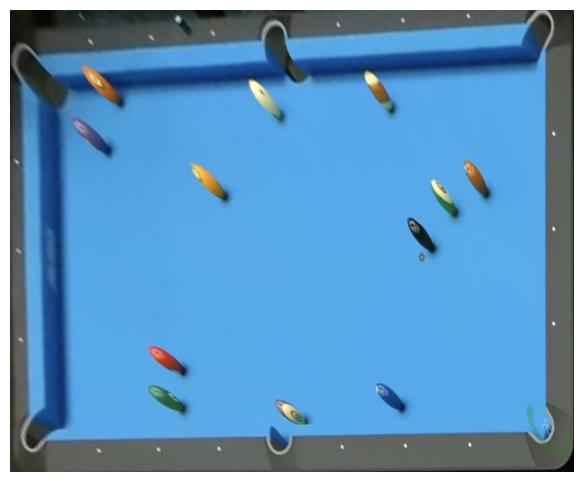

In [47]:
image_path = 'development_set/4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg'
img = cv2.imread(image_path)

border_top_view = get_top_view_image(img, debug=False)

if border_top_view is not None:
    plt.figure(figsize=(10, 6))
    plt.imshow(border_top_view)
    plt.axis('off')
    plt.show()

### Batch Pipeline

In [48]:
results = []

for image_path in image_paths:
    img = cv2.imread(image_path)

    if img is None:
        results.append({
            "image_path": image_path,
            "top_view_path": None,
            "status": "read_error"
        })
        continue

    border_top_view = get_top_view_image(img, debug=False)

    if border_top_view is None:
        results.append({
            "image_path": image_path,
            "top_view_path": None,
            "status": "processing_error"
        })
        continue

    original_name = os.path.basename(image_path)
    out_path = os.path.join(TOP_VIEW_DIR, original_name)

    cv2.imwrite(out_path, cv2.cvtColor(border_top_view, cv2.COLOR_RGB2BGR))

    results.append({
        "image_path": image_path,
        "top_view_path": out_path,
        "status": "ok"
    })

with open(TOP_VIEW_OUTPUT, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} results to '{TOP_VIEW_OUTPUT}'.")

Saved 50 results to 'top_views_output.json'.


## Bounding Boxes

In [111]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_images(img_path, debug=False):
    """Loads the image and returns it in BGR, RGB, and Grayscale formats."""
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Error: Image not found at {img_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if debug:
        print(f"Image loaded: {img_path}")
        print(f"Image shape: {img.shape}")

    return img, img_rgb, img_gray

def extract_table_masks(img, img_gray, lower_blue=(90, 50, 50), upper_blue=(130, 255, 255), debug=False):
    """Isolates the pool table and returns the visual and strict logical masks."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Create numpy arrays for HSV bounds
    lower_hsv = np.array(lower_blue)
    upper_hsv = np.array(upper_blue)
    
    # Threshold and clean up the mask
    mask_blue = cv2.inRange(hsv, lower_hsv, upper_hsv)
    kernel_roi = np.ones((5, 5), np.uint8)
    mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_CLOSE, kernel_roi)
    mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_OPEN, kernel_roi)

    contours, _ = cv2.findContours(mask_blue, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Warning: Table not found. Using fallback masks.")
        roi_mask = np.ones(img_gray.shape, dtype=np.uint8) * 255
        safe_zone_mask = roi_mask.copy()
        return roi_mask, safe_zone_mask

    # Process the largest contour
    table_contour = max(contours, key=cv2.contourArea)
    epsilon = 0.02 * cv2.arcLength(table_contour, True)
    approx_polygon = cv2.approxPolyDP(table_contour, epsilon, True)
    
    # 1. VISUAL MASK (Lightly eroded)
    roi_mask = np.zeros(img_gray.shape, dtype=np.uint8)
    cv2.drawContours(roi_mask, [approx_polygon], -1, 255, -1)
    roi_mask = cv2.erode(roi_mask, kernel_roi, iterations=3)
    
    # 2. LOGICAL MASK (Heavily eroded safe zone)
    safe_zone_mask = cv2.erode(roi_mask, kernel_roi, iterations=8)

    return roi_mask, safe_zone_mask

def preprocess_image(img_gray, roi_mask):
    """Applies filters and contrast enhancement, then masks the background."""
    bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(bilateral)
    
    # Black out everything outside the table
    masked_enhanced = cv2.bitwise_and(enhanced, enhanced, mask=roi_mask)
    
    return masked_enhanced

def detect_and_draw_boxes(masked_enhanced, img_rgb, safe_zone_mask, params=None):
    """Runs HoughCircles, filters by safe zone, and draws bounding boxes."""
    if params is None:
        params = {
            'dp': 1, 
            'minDist': 50, 
            'param1': 50, 
            'param2': 15, 
            'minRadius': 15, 
            'maxRadius': 35
        }

    circles = cv2.HoughCircles(
        masked_enhanced,
        cv2.HOUGH_GRADIENT,
        dp=params['dp'],
        minDist=params['minDist'],
        param1=params['param1'],
        param2=params['param2'],
        minRadius=params['minRadius'],
        maxRadius=params['maxRadius']
    )

    img_result = img_rgb.copy()
    detected_balls = 0

    if circles is not None:
        circles = np.uint16(np.around(circles))
        
        for i, circle in enumerate(circles[0, :]):
            x, y, r = circle
            
            # FINAL SPATIAL CHECK
            if safe_zone_mask[y, x] == 255:
                detected_balls += 1
                padding = 10
                
                # Bounding box coordinates
                x_min = max(0, x - r - 2 - padding)
                y_min = max(0, y - r - 2 - padding)
                x_max = min(img_rgb.shape[1], x + r + 2 + padding)
                y_max = min(img_rgb.shape[0], y + r + 2 + padding)
                
                # Draw box and center
                cv2.rectangle(img_result, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                cv2.circle(img_result, (x, y), 2, (255, 0, 0), -1)

    return img_result, detected_balls

def display_results(safe_zone_mask, img_result, detected_balls, debug=False):
    """Plots the safe zone mask and the final detection image side-by-side."""
    print(f"Detected {detected_balls} balls on the table.")
    

    if debug:
        fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        print("\n=== SAFE ZONE MASK ===")
        print(f"Mask shape: {safe_zone_mask.shape}")
        print(f"Unique values: {np.unique(safe_zone_mask)}")
        print(f"Non-zero count: {np.count_nonzero(safe_zone_mask)}")
        ax[0].imshow(safe_zone_mask, cmap='gray')
        ax[0].set_title("Table Logical Safe Zone Mask")
        ax[0].axis('off')
        ax[1].imshow(img_result)
        ax[1].set_title(f"Final Detection: {detected_balls} balls")
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()
    
    else:
        plt.figure(figsize=(10, 6))
        plt.imshow(img_result)
        plt.title(f"Detected Balls: {detected_balls}", fontweight='bold')
        plt.axis('off')
        plt.show()
    

def process_pool_table_image(img_path, debug=False, display=True):
    """Main pipeline function orchestrating the workflow."""
    
    # 1. Load Data
    img, img_rgb, img_gray = load_images(img_path, debug=debug)
    
    # 2. Extract Masks
    if debug:
        print("--- Extracting Table ROI ---")
    roi_mask, safe_zone_mask = extract_table_masks(img, img_gray, debug=debug)
    
    # 3. Preprocess
    if debug:
        print("--- Preprocessing ---")
    masked_enhanced = preprocess_image(img_gray, roi_mask)
    
    # 4. Detect Balls
    if debug:
        print("--- Detecting Balls within ROI ---")
    img_result, detected_balls = detect_and_draw_boxes(masked_enhanced, img_rgb, safe_zone_mask)
    
    # 5. Output Display
    if display:
        display_results(safe_zone_mask, img_result, detected_balls, debug=debug)

    return img_result, detected_balls

### Single Sample Check

Detected 15 balls on the table.


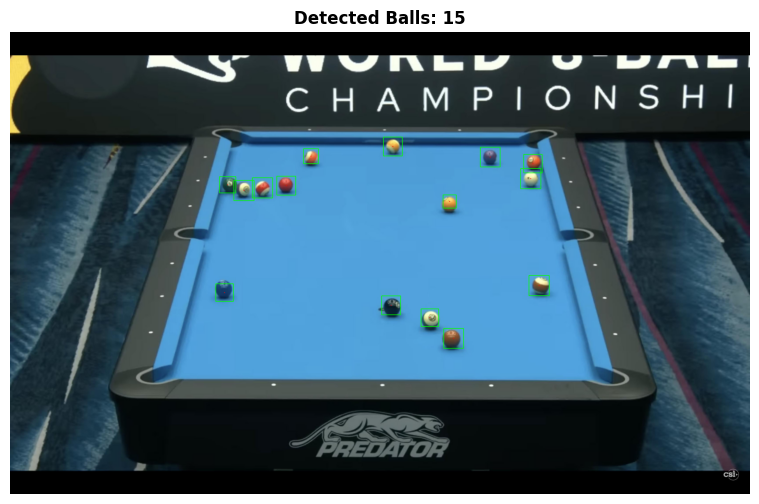

In [112]:
if __name__ == "__main__":
    IMAGE_PATH = './development_set/3f_png.rf.81c7e132365ef95bb19380ca389025f6.jpg'
    
    try:
        a, b = process_pool_table_image(IMAGE_PATH, debug=False, display=True)
    except Exception as e:
        print(e)

### Batch Pipeline

In [113]:
results_bounding_boxes = []

for image_path in image_paths:
    img = cv2.imread(image_path)

    if img is None:
        results_bounding_boxes.append({
            "image_path": image_path,
            "num_balls": None,
            "status": "read_error"
        })
        continue

    bounding_boxes_view, detected_balls = process_pool_table_image(image_path, debug=False, display=False)

    if bounding_boxes_view is None:
        results_bounding_boxes.append({
            "image_path": image_path,
            "num_balls": None,
            "status": "processing_error"
        })
        continue

    original_name = os.path.basename(image_path)
    out_path = os.path.join(BOUNDING_BOX_DIR, original_name)

    cv2.imwrite(out_path, cv2.cvtColor(bounding_boxes_view, cv2.COLOR_RGB2BGR))

    results_bounding_boxes.append({
        "image_path": image_path,
        "bounding_boxes_path": out_path,
        "num_balls": detected_balls,
        "status": "ok"
    })

with open(BOUNDING_BOX_OUTPUT, "w") as f:
    json.dump(results_bounding_boxes, f, indent=2)

print(f"Saved {len(results_bounding_boxes)} results to '{BOUNDING_BOX_OUTPUT}'.")

Saved 50 results to 'bounding_boxes_output.json'.
